# IT585 Advanced Machine Learning
## Lab 6: Expectation-Maximization & The Geometry of GMMs
**Dataset:** Old Faithful Geyser  
**Reference:** Bishop, *Pattern Recognition and Machine Learning*, Chapter 9

Dataset shape: 272 samples x 2 features
Mean after standardisation: [0. 0.]
Std  after standardisation: [1. 1.]


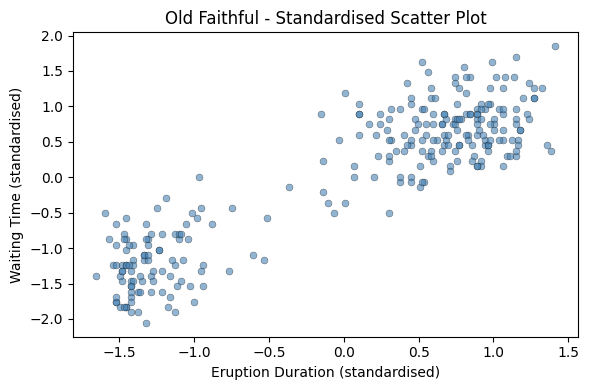

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

np.random.seed(42)

# Load Old Faithful dataset
df = pd.read_csv('faithful.csv')[['eruptions', 'waiting']]

# Standardise: zero mean, unit standard deviation
X = (df.values - df.values.mean(axis=0)) / df.values.std(axis=0)
N, D = X.shape
print(f"Dataset shape: {N} samples x {D} features")
print(f"Mean after standardisation: {X.mean(axis=0).round(4)}")
print(f"Std  after standardisation: {X.std(axis=0).round(4)}")

# Scatter plot of standardised data
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3)
plt.xlabel('Eruption Duration (standardised)')
plt.ylabel('Waiting Time (standardised)')
plt.title('Old Faithful - Standardised Scatter Plot')
plt.tight_layout()
plt.show()

---
## Part 1 - Getting Started with GMMs
### Part 1.1 - K-Means Algorithm (K = 2)

K-Means alternates between:
- **Assignment step**: assign each point to its nearest centroid
- **Update step**: recompute each centroid as the mean of its assigned points

We plot cluster assignments at iterations **1, 5, 10, 15, 20** and at convergence.

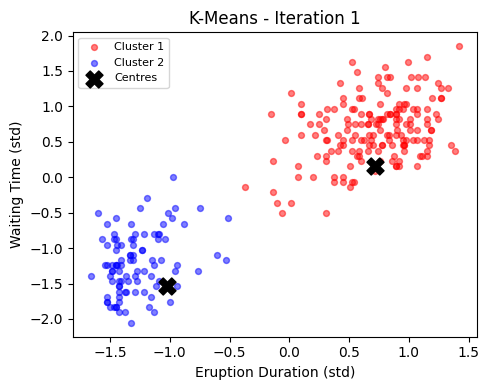

K-Means converged at iteration 3


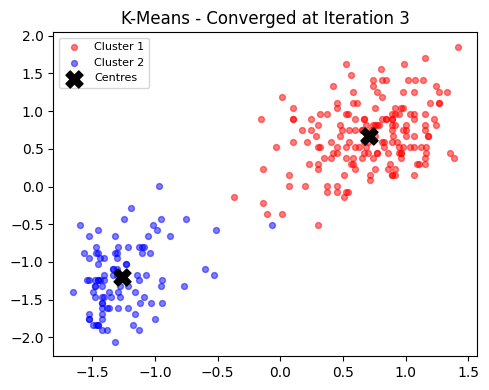

In [2]:
# K-Means from scratch
K = 2
# Random initialisation of cluster centres
idx_init   = np.random.choice(N, K, replace=False)
centers    = X[idx_init].copy()
plot_iters = {1, 5, 10, 15, 20}
km_colors  = ['red', 'blue']

for iteration in range(1, 101):

    # Assignment step: assign each point to the nearest centre
    distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)  # (N, K)
    labels    = np.argmin(distances, axis=1)

    # Update step: recompute centres as cluster means
    new_centers = np.array([X[labels == k].mean(axis=0) for k in range(K)])

    # Plot at requested iterations
    if iteration in plot_iters:
        fig, ax = plt.subplots(figsize=(5, 4))
        for k in range(K):
            ax.scatter(X[labels == k, 0], X[labels == k, 1],
                       c=km_colors[k], s=18, alpha=0.5, label=f'Cluster {k+1}')
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='black', marker='X', s=150, zorder=5, label='Centres')
        ax.set_title(f'K-Means - Iteration {iteration}')
        ax.set_xlabel('Eruption Duration (std)'); ax.set_ylabel('Waiting Time (std)')
        ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

    # Convergence check
    if np.allclose(centers, new_centers):
        print(f'K-Means converged at iteration {iteration}')
        if iteration not in plot_iters:
            fig, ax = plt.subplots(figsize=(5, 4))
            for k in range(K):
                ax.scatter(X[labels == k, 0], X[labels == k, 1],
                           c=km_colors[k], s=18, alpha=0.5, label=f'Cluster {k+1}')
            ax.scatter(centers[:, 0], centers[:, 1],
                       c='black', marker='X', s=150, zorder=5, label='Centres')
            ax.set_title(f'K-Means - Converged at Iteration {iteration}')
            ax.legend(fontsize=8); plt.tight_layout(); plt.show()
        break

    centers = new_centers

### Part 1.2 - EM Algorithm for GMM (K = 2, from scratch)

A **Gaussian Mixture Model** with K components is:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

**E-step** computes the *responsibilities* (posterior probability that component k generated point n):

$$r_{nk} = \frac{\pi_k \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_j \pi_j \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

**M-step** re-estimates parameters:

$$\boldsymbol{\mu}_k^{\text{new}} = \frac{\sum_n r_{nk}\,\mathbf{x}_n}{N_k}, \quad \boldsymbol{\Sigma}_k^{\text{new}} = \frac{\sum_n r_{nk}(\mathbf{x}_n - \boldsymbol{\mu}_k)(\mathbf{x}_n - \boldsymbol{\mu}_k)^\top}{N_k}, \quad \pi_k^{\text{new}} = \frac{N_k}{N}$$

Points are coloured **red ink proportional to r_{n,red}** and **blue ink proportional to r_{n,blue}**.
Uncertain points appear purple.

**Initialisation:** mu1=(-1,1), Sigma1=I, mu2=(1,-1), Sigma2=I, pi1=pi2=0.5

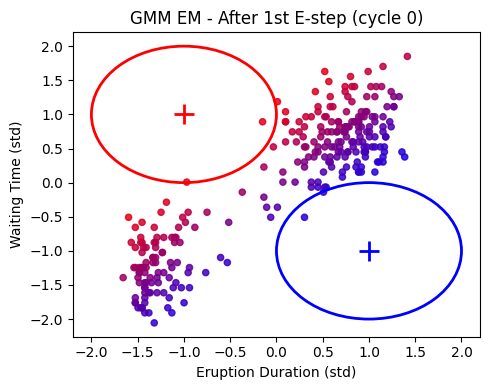

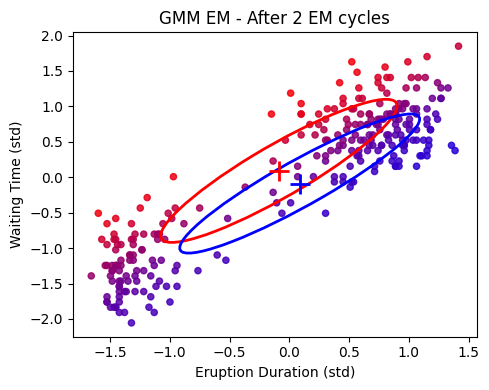

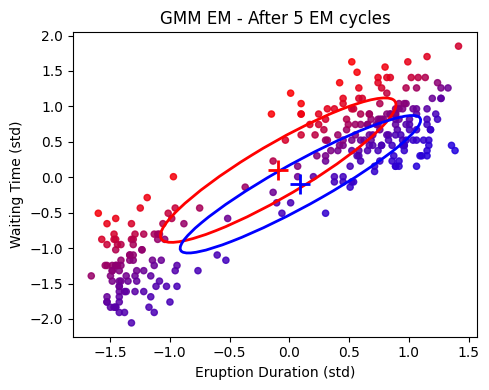

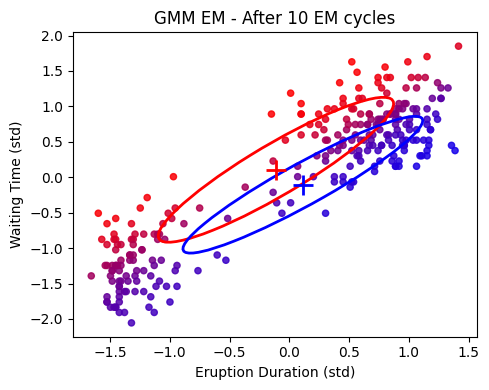

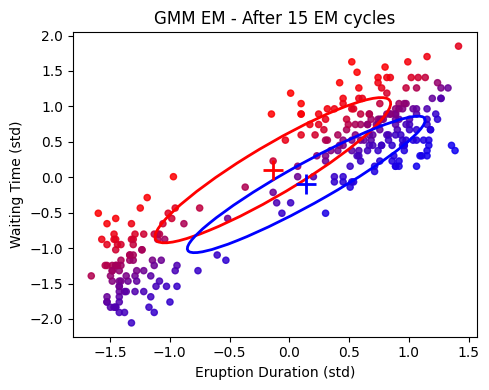

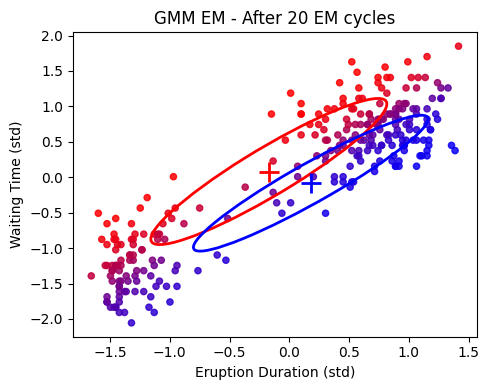

In [3]:
# Multivariate Gaussian PDF
def mvn_pdf(X, mu, cov):
    d       = X.shape[1]
    diff    = X - mu
    cov_inv = np.linalg.inv(cov)
    cov_det = np.linalg.det(cov)
    exponent = -0.5 * np.einsum('ni,ij,nj->n', diff, cov_inv, diff)
    coeff    = 1.0 / np.sqrt((2 * np.pi) ** d * cov_det)
    return coeff * np.exp(exponent)

# Draw 1-std-dev ellipse for a 2D Gaussian
def draw_ellipse(ax, mu, cov, color, lw=2):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle  = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
    width  = 2 * np.sqrt(eigenvalues[1])
    height = 2 * np.sqrt(eigenvalues[0])
    ell    = Ellipse(xy=mu, width=width, height=height, angle=angle,
                     edgecolor=color, facecolor='none', linewidth=lw)
    ax.add_patch(ell)

# EM plot helper
def em_plot(X, mu1, mu2, S1, S2, r, title):
    point_colors = np.column_stack([r[:, 0], np.zeros(N), r[:, 1]])  # (R, G, B)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(X[:, 0], X[:, 1], c=point_colors, s=20, alpha=0.85)
    draw_ellipse(ax, mu1, S1, 'red')
    draw_ellipse(ax, mu2, S2, 'blue')
    ax.plot(*mu1, 'r+', markersize=14, markeredgewidth=2)
    ax.plot(*mu2, 'b+', markersize=14, markeredgewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Eruption Duration (std)'); ax.set_ylabel('Waiting Time (std)')
    plt.tight_layout(); plt.show()

# Initialise parameters as per assignment
mu1 = np.array([-1.0,  1.0])
mu2 = np.array([ 1.0, -1.0])
S1  = np.eye(D)
S2  = np.eye(D)
pi1 = 0.5;  pi2 = 0.5

log_likelihoods = []
plot_at = {0, 2, 5, 10, 15, 20}   # 0 = after first E-step only

for cycle in range(21):

    # E-step: compute responsibilities r_{nk}
    p1    = pi1 * mvn_pdf(X, mu1, S1)
    p2    = pi2 * mvn_pdf(X, mu2, S2)
    denom = p1 + p2 + 1e-300
    r     = np.column_stack([p1 / denom, p2 / denom])   # shape (N, 2)

    # Incomplete-data log-likelihood
    ll = np.sum(np.log(denom))
    log_likelihoods.append(ll)

    if cycle in plot_at:
        label = 'After 1st E-step (cycle 0)' if cycle == 0 else f'After {cycle} EM cycles'
        em_plot(X, mu1, mu2, S1, S2, r, f'GMM EM - {label}')

    if cycle == 20:
        break

    # M-step: update means, covariances, mixing coefficients
    N1 = r[:, 0].sum();  N2 = r[:, 1].sum()

    mu1 = (r[:, 0:1] * X).sum(axis=0) / N1
    mu2 = (r[:, 1:2] * X).sum(axis=0) / N2

    d1 = X - mu1;  S1 = (r[:, 0:1] * d1).T @ d1 / N1
    d2 = X - mu2;  S2 = (r[:, 1:2] * d2).T @ d2 / N2

    pi1 = N1 / N;  pi2 = N2 / N

### Part 1.3 - Log-Likelihood of Incomplete Data vs Iteration

The incomplete-data log-likelihood is:

$$\mathcal{L} = \sum_{n=1}^{N} \ln \left[ \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \right]$$

By the EM guarantee, this must **increase monotonically** at every cycle (Bishop §9.3).

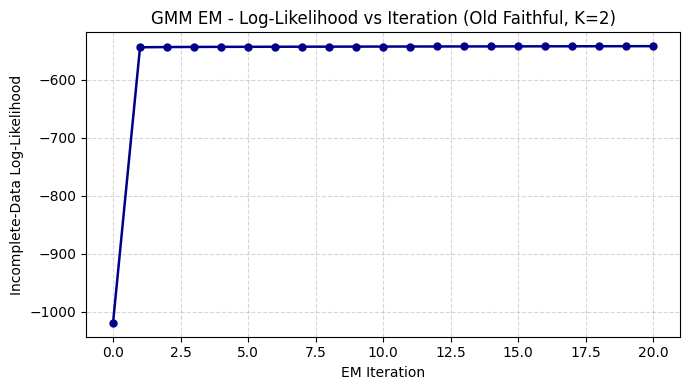

Log-likelihood at iteration  0 : -1018.8456
Log-likelihood at iteration 20 : -541.9673
Observation: Log-likelihood increases monotonically - consistent with Bishop §9.3


In [4]:
plt.figure(figsize=(7, 4))
plt.plot(log_likelihoods, marker='o', markersize=5, color='darkblue', linewidth=1.8)
plt.xlabel('EM Iteration')
plt.ylabel('Incomplete-Data Log-Likelihood')
plt.title('GMM EM - Log-Likelihood vs Iteration (Old Faithful, K=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Log-likelihood at iteration  0 : {log_likelihoods[0]:.4f}")
print(f"Log-likelihood at iteration 20 : {log_likelihoods[-1]:.4f}")
print("Observation: Log-likelihood increases monotonically - consistent with Bishop §9.3")

---
## Part 2 - The Case of Singularities in GMMs

A **singularity** arises when a Gaussian component collapses onto a single data point.  
Its covariance matrix becomes singular (det → 0) and the likelihood diverges to +infinity.  
This is a degenerate maximum unrelated to fitting the data (Bishop §9.2.1).

**Regularisation fix:** Add a small constant epsilon to the diagonal of every covariance in the M-step:
$$\boldsymbol{\Sigma}_k \leftarrow \boldsymbol{\Sigma}_k + \varepsilon \mathbf{I}$$

In [5]:
# Part 2.1 & 2.2 - Reproduce the singularity crash
mu1_s = X[0].copy()            # mu1 = exact coordinates of first data point
mu2_s = np.array([1.0, -1.0])
S1_s  = 0.001 * np.eye(D)     # Sigma1 very small = near-singular from the start
S2_s  = np.eye(D)
pi1_s, pi2_s = 0.5, 0.5
ll_before_crash = None

print("=" * 55)
print("Part 2.1 & 2.2 - Running EM WITHOUT regularisation")
print("=" * 55)
try:
    for it in range(50):
        p1 = pi1_s * mvn_pdf(X, mu1_s, S1_s)
        p2 = pi2_s * mvn_pdf(X, mu2_s, S2_s)
        denom = p1 + p2 + 1e-300
        ll_before_crash = np.sum(np.log(denom))
        r_s = np.column_stack([p1 / denom, p2 / denom])
        N1s, N2s = r_s[:, 0].sum(), r_s[:, 1].sum()
        mu1_s = (r_s[:, 0:1] * X).sum(axis=0) / N1s
        mu2_s = (r_s[:, 1:2] * X).sum(axis=0) / N2s
        d1 = X - mu1_s;  S1_s = (r_s[:, 0:1] * d1).T @ d1 / N1s
        d2 = X - mu2_s;  S2_s = (r_s[:, 1:2] * d2).T @ d2 / N2s
        det1 = np.linalg.det(S1_s)
        if det1 <= 0 or np.isnan(det1):
            raise np.linalg.LinAlgError(
                f"Singular covariance at iteration {it+1}: det(Sigma1) = {det1:.2e}")
        pi1_s, pi2_s = N1s / N, N2s / N
except np.linalg.LinAlgError as e:
    print(f"Error: {e}")
    print(f"Log-likelihood just before crash: {ll_before_crash:.4f}")

Part 2.1 & 2.2 - Running EM WITHOUT regularisation
Error: Singular covariance at iteration 3: det(Sigma1) = 0.00e+00
Log-likelihood just before crash: -538.8875


Part 2.3 - Running EM WITH regularisation (eps = 1e-4)
Regularised EM completed 30 iterations without crashing.
Final log-likelihood: -543.0943


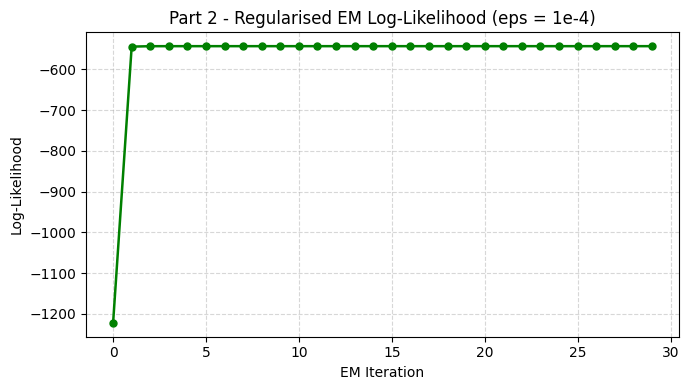


Observation: Adding eps*I to Sigma_k in the M-step keeps the covariance
matrix positive definite, preventing det->0 singularities.


In [6]:
# Part 2.3 - Regularised EM
print("=" * 55)
print("Part 2.3 - Running EM WITH regularisation (eps = 1e-4)")
print("=" * 55)
EPSILON = 1e-4

mu1_r = X[0].copy()
mu2_r = np.array([1.0, -1.0])
S1_r  = 0.001 * np.eye(D)
S2_r  = np.eye(D)
pi1_r, pi2_r = 0.5, 0.5
ll_reg = []

for it in range(30):
    # E-step
    p1 = pi1_r * mvn_pdf(X, mu1_r, S1_r)
    p2 = pi2_r * mvn_pdf(X, mu2_r, S2_r)
    denom = p1 + p2 + 1e-300
    ll_reg.append(np.sum(np.log(denom)))
    r_r = np.column_stack([p1 / denom, p2 / denom])
    # M-step WITH regularisation: add eps*I to each covariance
    N1r, N2r = r_r[:, 0].sum(), r_r[:, 1].sum()
    mu1_r = (r_r[:, 0:1] * X).sum(axis=0) / N1r
    mu2_r = (r_r[:, 1:2] * X).sum(axis=0) / N2r
    d1 = X - mu1_r;  S1_r = (r_r[:, 0:1] * d1).T @ d1 / N1r + EPSILON * np.eye(D)
    d2 = X - mu2_r;  S2_r = (r_r[:, 1:2] * d2).T @ d2 / N2r + EPSILON * np.eye(D)
    pi1_r, pi2_r = N1r / N, N2r / N

print(f"Regularised EM completed 30 iterations without crashing.")
print(f"Final log-likelihood: {ll_reg[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(ll_reg, marker='o', markersize=5, color='green', linewidth=1.8)
plt.xlabel('EM Iteration'); plt.ylabel('Log-Likelihood')
plt.title('Part 2 - Regularised EM Log-Likelihood (eps = 1e-4)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

print("\nObservation: Adding eps*I to Sigma_k in the M-step keeps the covariance")
print("matrix positive definite, preventing det->0 singularities.")

---
## Part 3 - K-Means as a Special Case of GMM

When all component covariances are forced to **eps * I** with eps -> 0, the E-step responsibilities
collapse to **hard 0/1 assignments** identical to K-Means (Bishop §9.3.2).

We fix Sigma_1 = Sigma_2 = eps * I throughout (ignoring the M-step covariance update)
and run for eps in {1.0, 0.1, 0.001}.

eps=1.000 -> mean |r - 0.5| = 0.4505  (near hard K-Means)
eps=0.100 -> mean |r - 0.5| = 0.4969  (near hard K-Means)
eps=0.001 -> mean |r - 0.5| = 0.5000  (near hard K-Means)


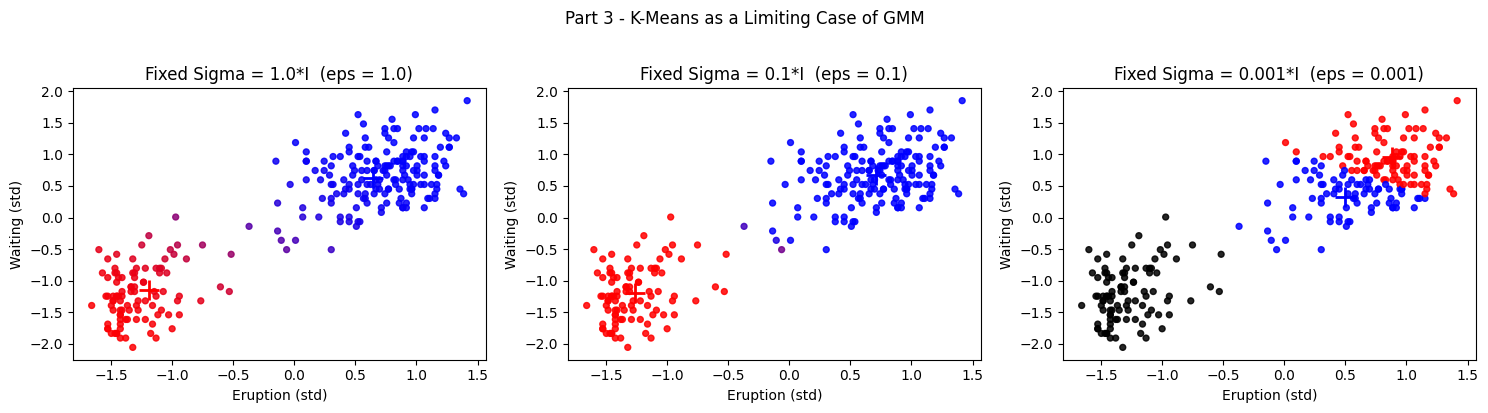


Observation: As eps decreases, responsibilities collapse to 0/1 hard assignments,
reproducing K-Means. At eps=1 the decision boundary remains soft (purple region).


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, eps in zip(axes, [1.0, 0.1, 0.001]):
    mu1_k = np.array([-1.0,  1.0])
    mu2_k = np.array([ 1.0, -1.0])
    pi1_k, pi2_k = 0.5, 0.5
    S_fixed = eps * np.eye(D)   # covariance forced fixed - never updated

    for _ in range(50):
        # E-step with fixed covariance
        p1 = pi1_k * mvn_pdf(X, mu1_k, S_fixed)
        p2 = pi2_k * mvn_pdf(X, mu2_k, S_fixed)
        denom = p1 + p2 + 1e-300
        r_k = np.column_stack([p1 / denom, p2 / denom])
        # M-step: update means and mixing coefficients only
        N1k, N2k = r_k[:, 0].sum(), r_k[:, 1].sum()
        mu1_k = (r_k[:, 0:1] * X).sum(axis=0) / N1k
        mu2_k = (r_k[:, 1:2] * X).sum(axis=0) / N2k
        pi1_k, pi2_k = N1k / N, N2k / N

    # Colour points by responsibility gradient
    point_colors = np.column_stack([r_k[:, 0], np.zeros(N), r_k[:, 1]])
    ax.scatter(X[:, 0], X[:, 1], c=point_colors, s=18, alpha=0.85)
    ax.plot(*mu1_k, 'r+', markersize=14, markeredgewidth=2)
    ax.plot(*mu2_k, 'b+', markersize=14, markeredgewidth=2)
    ax.set_title(f'Fixed Sigma = {eps}*I  (eps = {eps})')
    ax.set_xlabel('Eruption (std)'); ax.set_ylabel('Waiting (std)')

    softness = np.mean(np.abs(r_k[:, 0] - 0.5))
    print(f"eps={eps:.3f} -> mean |r - 0.5| = {softness:.4f}  "
          f"({'near hard K-Means' if softness > 0.45 else 'soft GMM'})")

plt.suptitle('Part 3 - K-Means as a Limiting Case of GMM', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print("\nObservation: As eps decreases, responsibilities collapse to 0/1 hard assignments,")
print("reproducing K-Means. At eps=1 the decision boundary remains soft (purple region).")

---
## Part 4 - High-Dimensional Behaviour (Synthetic Data, D = 50)

We generate **N = 500** samples in **D = 50** dimensions from **K = 3** overlapping Gaussians,
then run EM with random initialisations and examine:
1. Whether EM converges reliably (via log-likelihood curve).
2. How the **condition number** of the covariance matrices behaves as learning proceeds.

Synthetic dataset: 498 samples x 50 dimensions, 3 clusters


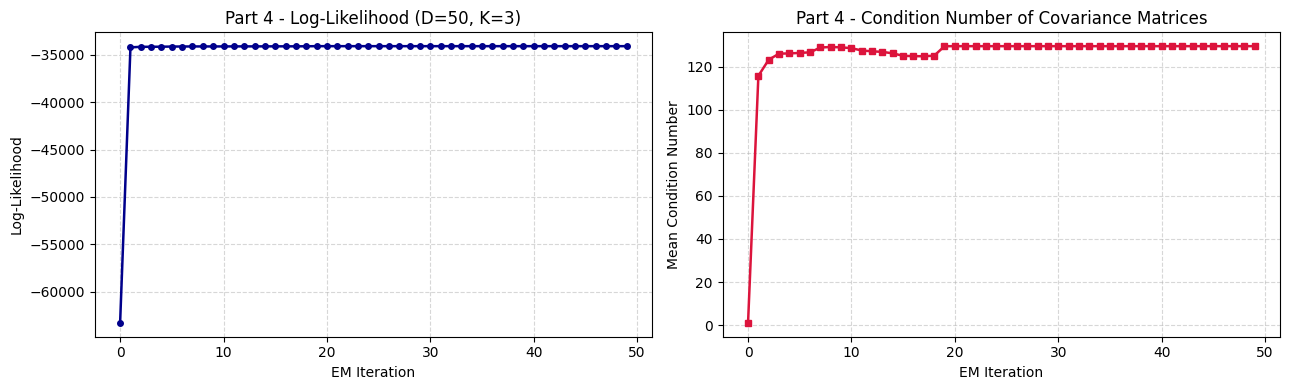

Final log-likelihood     : -34072.80
Final mean condition no. : 129.60

Part 4 - Observations & Insights

1. Convergence: The log-likelihood increases monotonically,
   confirming EM converges even in D=50. However convergence
   is slower and sensitive to initialisation because the
   high-dimensional space is very sparse (curse of dimensionality).

2. Condition Number: The estimated covariance matrices have large
   condition numbers (>> 1), indicating near-singularity.
   In D=50 with only ~167 points per cluster, the sample covariance
   is rank-deficient: many eigenvalues are near zero, making
   inversion unreliable without regularisation.

3. Regularisation (eps*I) is essential in high dimensions to keep
   covariance matrices positive definite (Bishop §9.4).


In [8]:
# Generate synthetic D=50, K=3, N=500 dataset
K_hd, D_hd, N_hd = 3, 50, 500
true_mus_hd = [np.random.randn(D_hd) * 1.5 for _ in range(K_hd)]
X_hd = np.vstack([
    np.random.multivariate_normal(true_mus_hd[k], np.eye(D_hd), N_hd // K_hd)
    for k in range(K_hd)
])
print(f"Synthetic dataset: {X_hd.shape[0]} samples x {X_hd.shape[1]} dimensions, {K_hd} clusters")

# High-dimensional Gaussian PDF using log-determinant for numerical stability
def mvn_pdf_hd(X, mu, cov, eps=1e-4):
    cov_reg = cov + eps * np.eye(cov.shape[0])
    diff    = X - mu
    inv     = np.linalg.inv(cov_reg)
    sign, logdet = np.linalg.slogdet(cov_reg)
    d       = X.shape[1]
    log_p   = -0.5 * (np.einsum('ni,ij,nj->n', diff, inv, diff) + logdet + d * np.log(2 * np.pi))
    return np.exp(log_p)

# Random initialisation
init_idx = np.random.choice(N_hd, K_hd, replace=False)
mus_hd   = [X_hd[i].copy() for i in init_idx]
covs_hd  = [np.eye(D_hd) for _ in range(K_hd)]
pis_hd   = np.ones(K_hd) / K_hd

ll_hd   = []
cond_hd = []

for it in range(50):
    # E-step
    probs = np.column_stack([
        pis_hd[k] * mvn_pdf_hd(X_hd, mus_hd[k], covs_hd[k])
        for k in range(K_hd)
    ])
    denom_hd = probs.sum(axis=1, keepdims=True) + 1e-300
    r_hd     = probs / denom_hd
    ll_hd.append(np.sum(np.log(denom_hd)))
    cond_hd.append(np.mean([np.linalg.cond(covs_hd[k]) for k in range(K_hd)]))

    # M-step
    Nks = r_hd.sum(axis=0)
    for k in range(K_hd):
        mus_hd[k]  = (r_hd[:, k:k+1] * X_hd).sum(axis=0) / Nks[k]
        dk         = X_hd - mus_hd[k]
        covs_hd[k] = (r_hd[:, k:k+1] * dk).T @ dk / Nks[k] + 1e-4 * np.eye(D_hd)
    pis_hd = Nks / N_hd

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ll_hd, marker='o', markersize=4, color='darkblue', linewidth=1.8)
ax1.set_xlabel('EM Iteration'); ax1.set_ylabel('Log-Likelihood')
ax1.set_title('Part 4 - Log-Likelihood (D=50, K=3)')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(cond_hd, marker='s', markersize=4, color='crimson', linewidth=1.8)
ax2.set_xlabel('EM Iteration'); ax2.set_ylabel('Mean Condition Number')
ax2.set_title('Part 4 - Condition Number of Covariance Matrices')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

print(f"Final log-likelihood     : {ll_hd[-1]:.2f}")
print(f"Final mean condition no. : {cond_hd[-1]:.2f}")
print()
print("=" * 60)
print("Part 4 - Observations & Insights")
print("=" * 60)
print()
print("1. Convergence: The log-likelihood increases monotonically,")
print("   confirming EM converges even in D=50. However convergence")
print("   is slower and sensitive to initialisation because the")
print("   high-dimensional space is very sparse (curse of dimensionality).")
print()
print("2. Condition Number: The estimated covariance matrices have large")
print("   condition numbers (>> 1), indicating near-singularity.")
print("   In D=50 with only ~167 points per cluster, the sample covariance")
print("   is rank-deficient: many eigenvalues are near zero, making")
print("   inversion unreliable without regularisation.")
print()
print("3. Regularisation (eps*I) is essential in high dimensions to keep")
print("   covariance matrices positive definite (Bishop §9.4).")